Данные на основе работы https://iopscience.iop.org/article/10.3847/1538-3881/ad83d3
для внутреннего решения (2:1)

Интервал $10^8$ лет, шаг записи $100$ лет.


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

    

In [2]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

2026-06-09 16:14:58.992066: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import numpy as np

In [30]:
data_path=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_2_resonance_3_1.npz'
data = np.load(data_path)
print(data.files) 

['time', 'phi_0_raw', 'phi_1_raw', 'phi_2_raw']


In [31]:
data['phi_0_raw']

array([ 313.20314346,  816.47026066,  451.02439192, ..., -187.7113708 ,
        177.71515807, -124.02430361], shape=(1000000,))

In [4]:

data_path=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_2_resonance_3_1.npz'
data = load_angles(data_path, angle_columns=['phi_0_raw', 'phi_1_raw', 'phi_2_raw'],
                   time_column='time', angle_unit='deg', convert_to_xy=True)


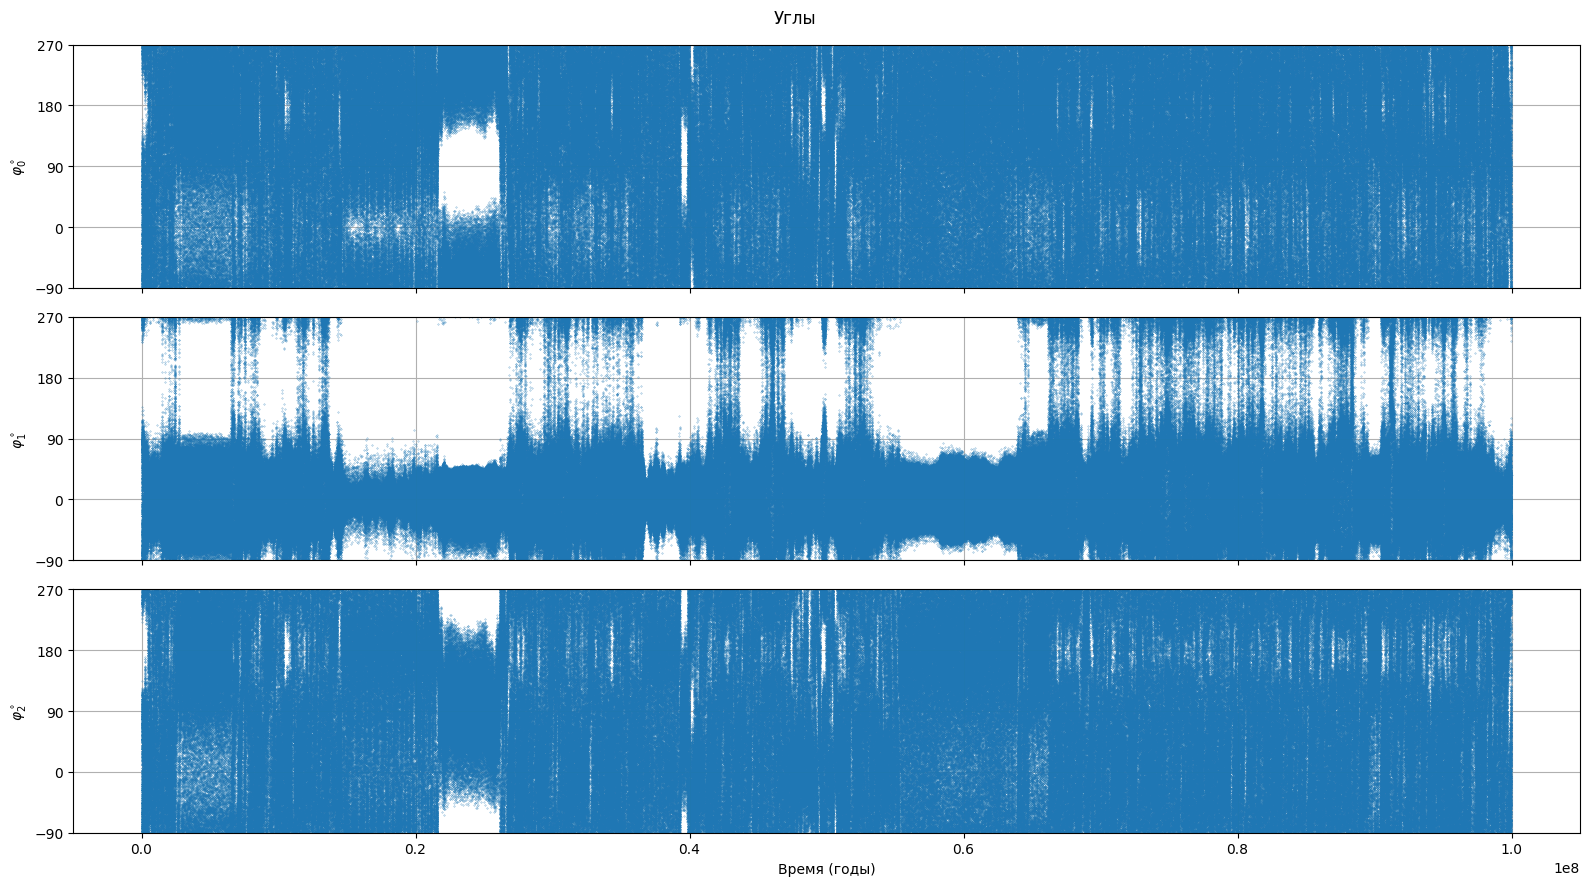

In [5]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы',
            fig_width=16.,
            row_height=3.,)

In [6]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)

In [7]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

W0000 00:00:1781003724.932531   10825 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [8]:
probs = predict_multiplet(windows['angle_windows'], model)

2026-06-09 16:15:25.890228: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-06-09 16:15:29.875249: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-06-09 16:15:29.972413: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-06-09 16:15:30.017601: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.
2026-06-09 16:15:30.102114: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32768000 exceeds 10% of free system memory.


In [9]:
classes = [predict_classes_from_proba(p) for p in probs]

In [10]:
classes

[array([1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2,
        1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1,
        1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2,
        2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2,
        2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 0, 2, 1, 0, 0, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0,
        0, 2, 2, 1, 1, 1, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2,
        1, 1, 2, 1, 1, 1, 1, 1]),
 array([1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
        1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    

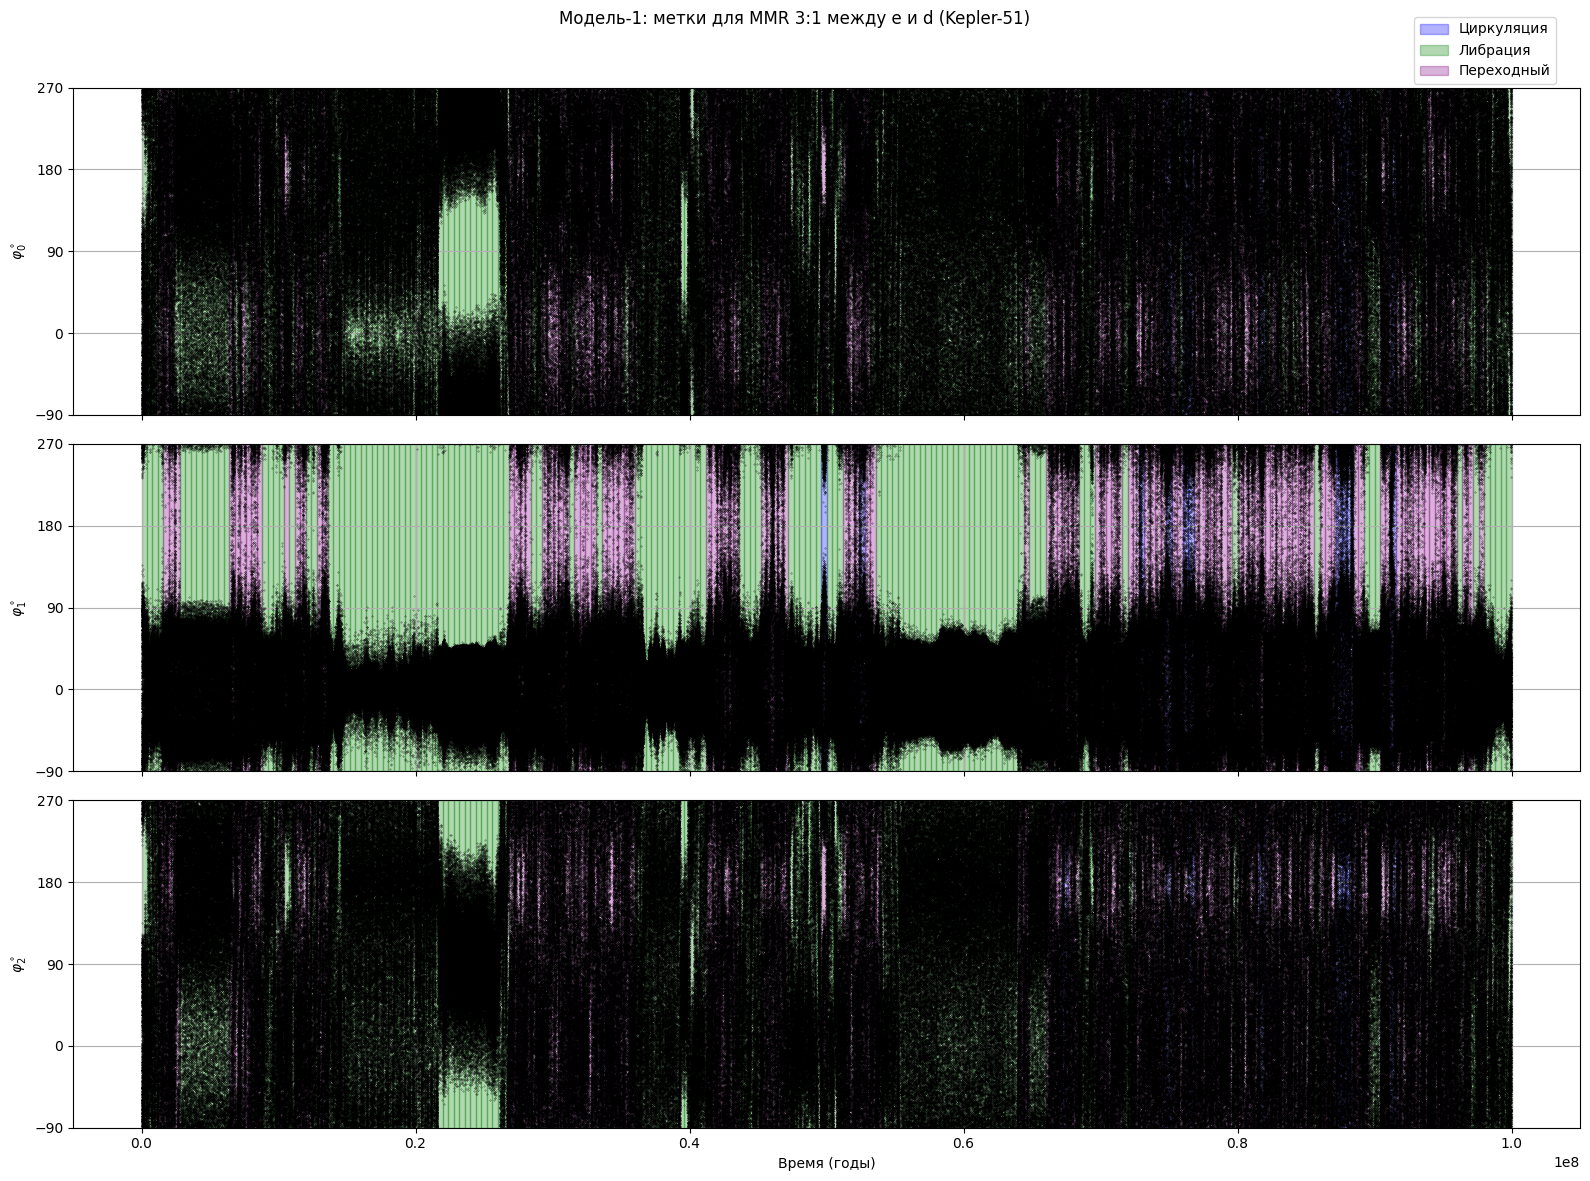

In [11]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для MMR 3:1 между e и d (Kepler-51)',
    fig_width=16.,
    row_height=4.,
    save_path=str(PROJECT_ROOT)+'/notebook/predict_Kepler51_MMR_model1.png'

)

In [12]:
model2 = load_model('2', models_dir=str(PROJECT_ROOT)+'/models/')

In [13]:
probs2 = predict_multiplet(windows['angle_windows'], model2)

In [14]:
classes2 = [predict_classes_from_proba(p) for p in probs2]

In [15]:
classes2

[array([1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 1, 2, 2, 2]),
 array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    

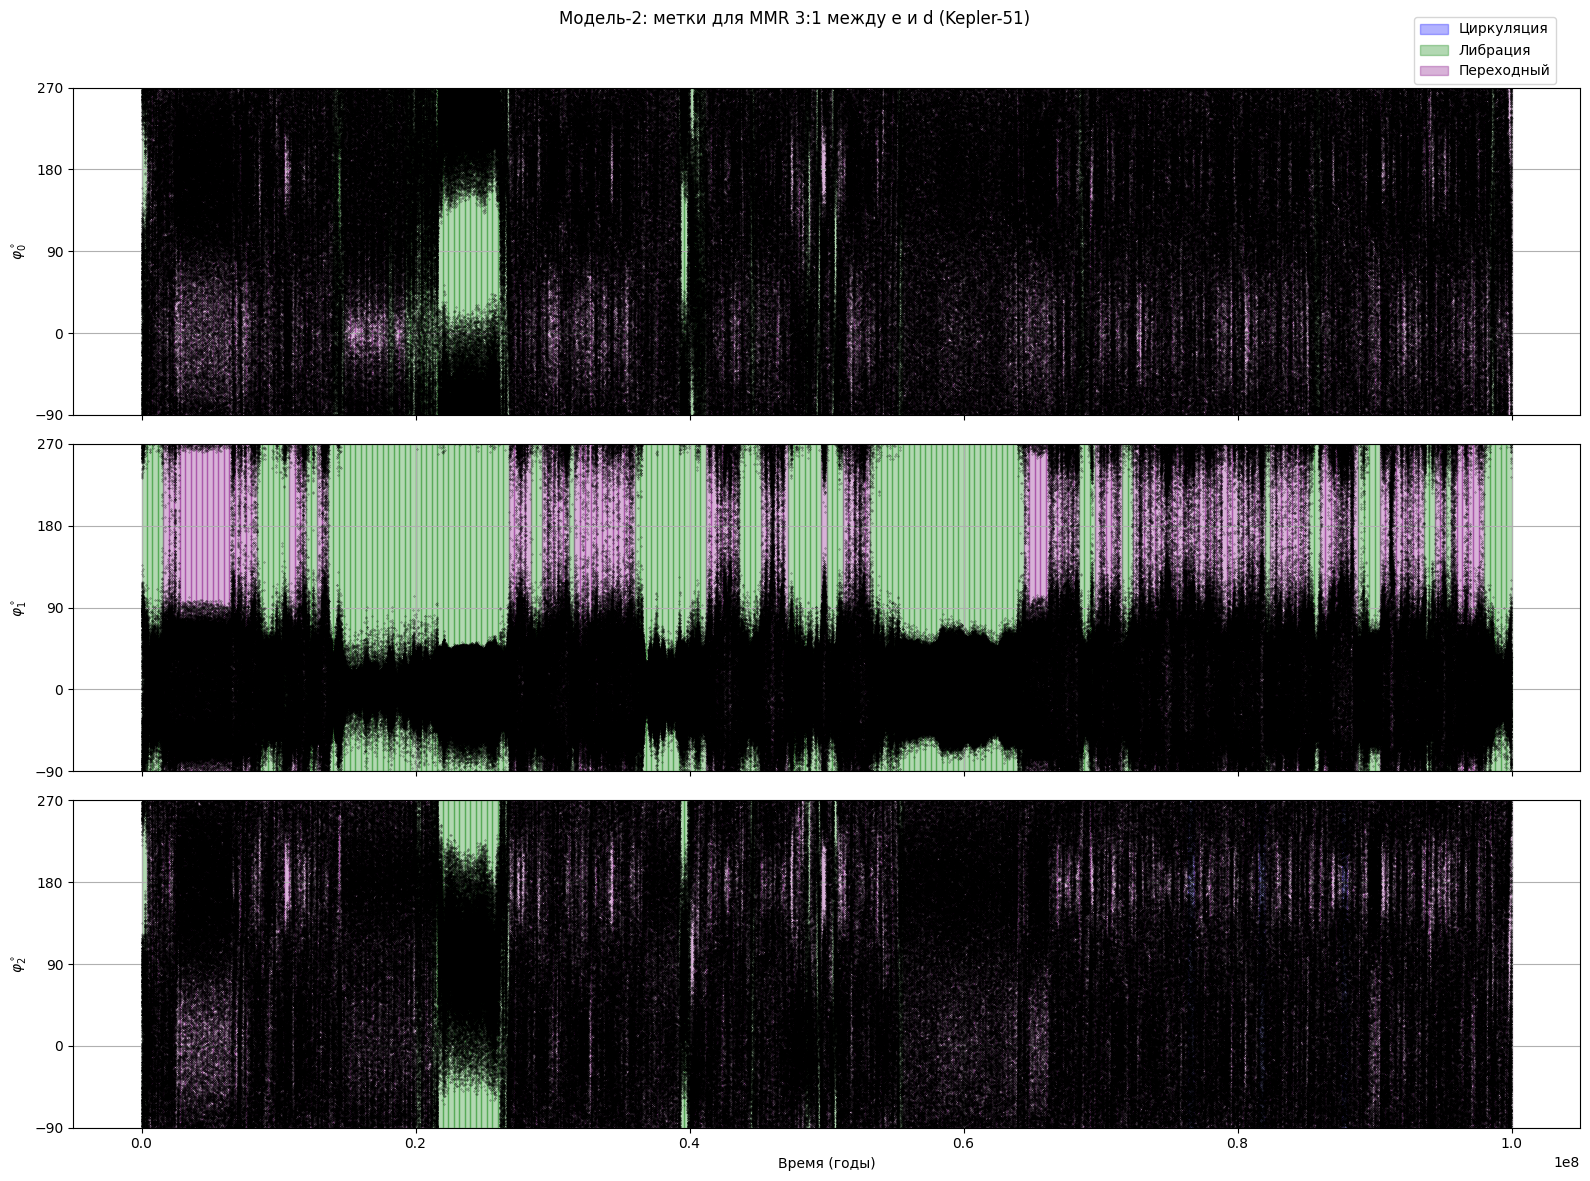

In [16]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes2,
    title='Модель-2: метки для MMR 3:1 между e и d (Kepler-51)',
    fig_width=16.,
    row_height=4.,
    save_path=str(PROJECT_ROOT)+'/notebook/predict_Kepler51_MMR_model2.png'

)

Модель некорректно классифицирует окна, веротяные проблемы:
1. Шаг между данными вырос в 40 раз (наиболее вероятный вариант)
2. Неправильная передача данных

In [ ]:
#Перекрытие в 1\2 окна

In [4]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.5,
)

In [5]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

W0000 00:00:1780776396.622282   69186 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
probs = predict_multiplet(windows['angle_windows'], model)

In [10]:
probs

[array([[4.3628080e-07, 9.7444910e-01, 2.5550447e-02],
        [5.4845596e-06, 9.5934123e-01, 4.0653344e-02],
        [5.0819563e-05, 9.4784403e-01, 5.2105203e-02],
        ...,
        [5.6677801e-03, 9.7384983e-01, 2.0482453e-02],
        [7.2480028e-04, 9.9069923e-01, 8.5760271e-03],
        [7.1938966e-06, 9.9595696e-01, 4.0357611e-03]],
       shape=(499, 3), dtype=float32),
 array([[2.5860156e-06, 9.8780924e-01, 1.2188083e-02],
        [4.8008395e-05, 9.9978733e-01, 1.6476224e-04],
        [8.5356412e-05, 9.9986482e-01, 4.9791186e-05],
        ...,
        [1.1664507e-05, 9.9997258e-01, 1.5739091e-05],
        [3.6212007e-06, 9.9999022e-01, 6.2256672e-06],
        [9.7512639e-06, 9.9973100e-01, 2.5920218e-04]],
       shape=(499, 3), dtype=float32),
 array([[3.9683133e-07, 9.7422099e-01, 2.5778590e-02],
        [2.6142136e-06, 9.0655792e-01, 9.3439527e-02],
        [1.5584748e-05, 8.6774671e-01, 1.3223770e-01],
        ...,
        [4.6427604e-03, 8.4371293e-01, 1.5164427e-01],
 

In [7]:
classes = [predict_classes_from_proba(p) for p in probs]

In [8]:
classes

[array([1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 1,
        1, 1, 1, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

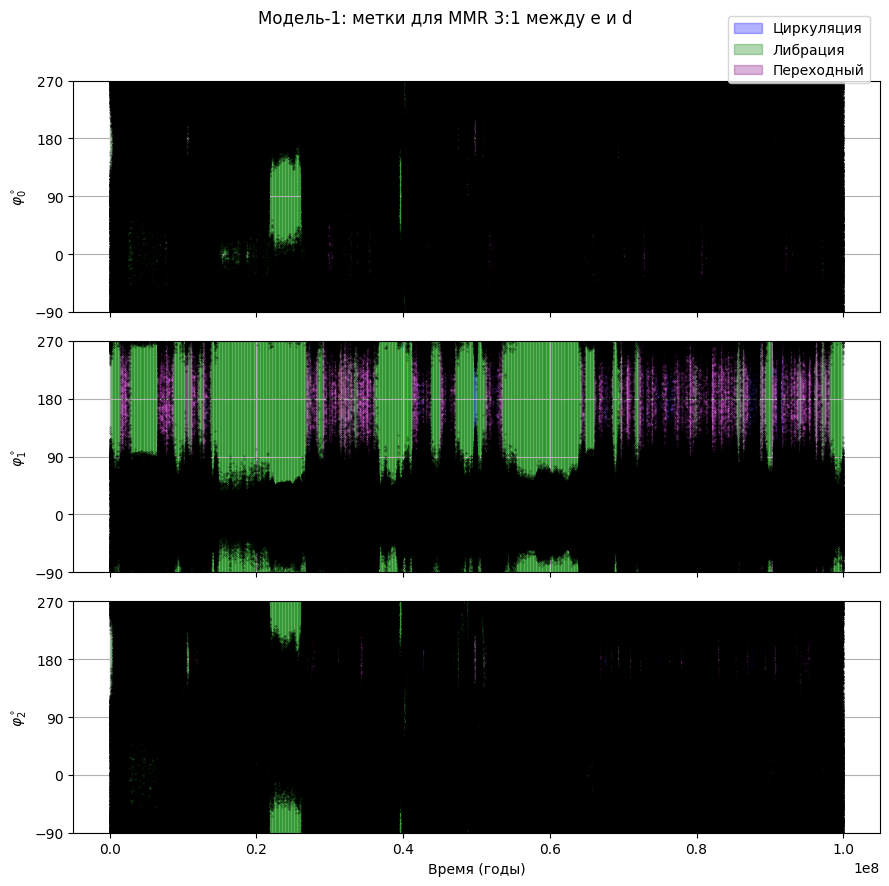

In [9]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для MMR 3:1 между e и d (Kepler-51)',
    fig_width=9.,
    row_height=3.,
    # save_path=str(PROJECT_ROOT)+'/notebook/predict_TOI1136_model1.png'

)

In [24]:
import numpy as np
data_path_seq=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_1_secular.npz'
data_s = np.load(data_path_seq)
print(data_s.files) 

['time', 'delta_longitude_raw']


In [31]:
#Вековой

data_path_seq=str(PROJECT_ROOT)+'/time_series/angles_inside_2_1/8_mmr/kepler-51_elem_1_secular.npz'
data_seq = load_angles(data_path_seq, angle_columns=['delta_longitude_raw'],
                   time_column='time', angle_unit='deg', convert_to_xy=True)

In [32]:
windows_seq = sliding_windows_multiplet(
    data_dict=data_seq,
    window_length=4000,
    overlap_ratio=0.
)

In [33]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

In [34]:
probs = predict_multiplet(windows_seq['angle_windows'], model)

In [35]:
classes = [predict_classes_from_proba(p) for p in probs]

In [36]:
classes

[array([2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 2, 2,
        2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0,
        2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2,
        2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2])]

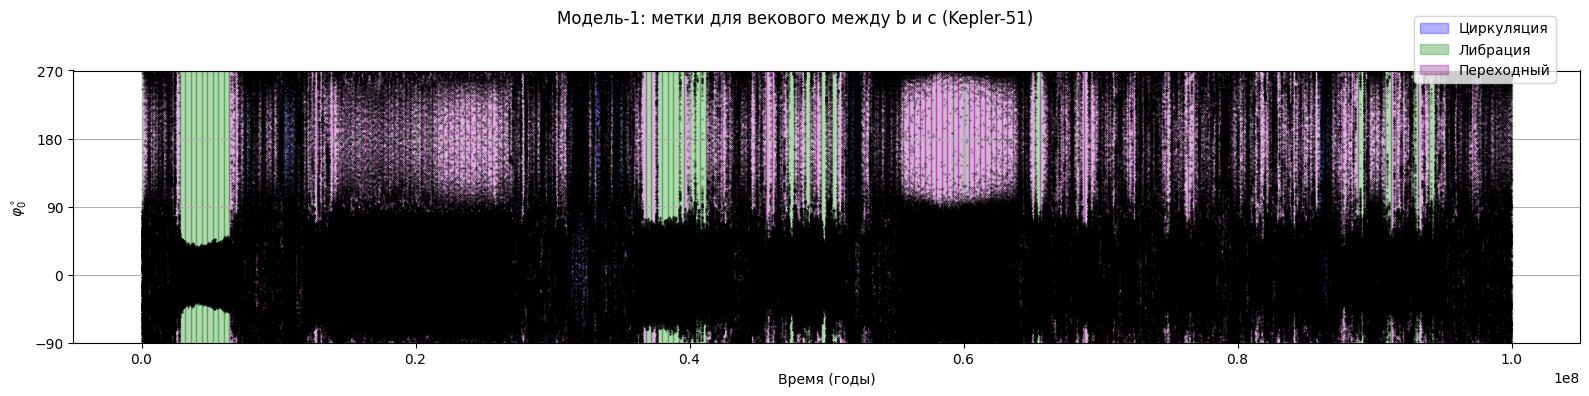

In [37]:
plot_multiplet_predictions(
    time_years=data_seq['time_years'],
    angles_deg_list=data_seq['angles_deg'],
    window_bounds=windows_seq['window_bounds'],
    class_labels_list=classes,
    title='Модель-1: метки для векового между b и c (Kepler-51)',
    fig_width=16.,
    row_height=4,
    save_path=str(PROJECT_ROOT)+'/notebook/predict_Kepler51_seq_model1.png'

)

Увеличение шага в 40 раз, не так значительно сказывается на вековых углав (долгопериодические переменные), в отличии от резонансов средних движений, которые уже содержат быстрые (срдние движения; средние аномалии).
Характерные признаки не замылись для вековых углов при переходе от 2.5 лет к 100 годам между точками

In [38]:
model2 = load_model('2', models_dir=str(PROJECT_ROOT)+'/models/')

In [39]:
probs2 = predict_multiplet(windows_seq['angle_windows'], model2)

In [40]:
classes2 = [predict_classes_from_proba(p) for p in probs2]

In [41]:
classes2

[array([1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 2,
        2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1,
        2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0,
        2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
        2, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 0, 2,
        2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2,
        2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
        2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 1, 2, 0, 2, 2, 1,
        1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2])]

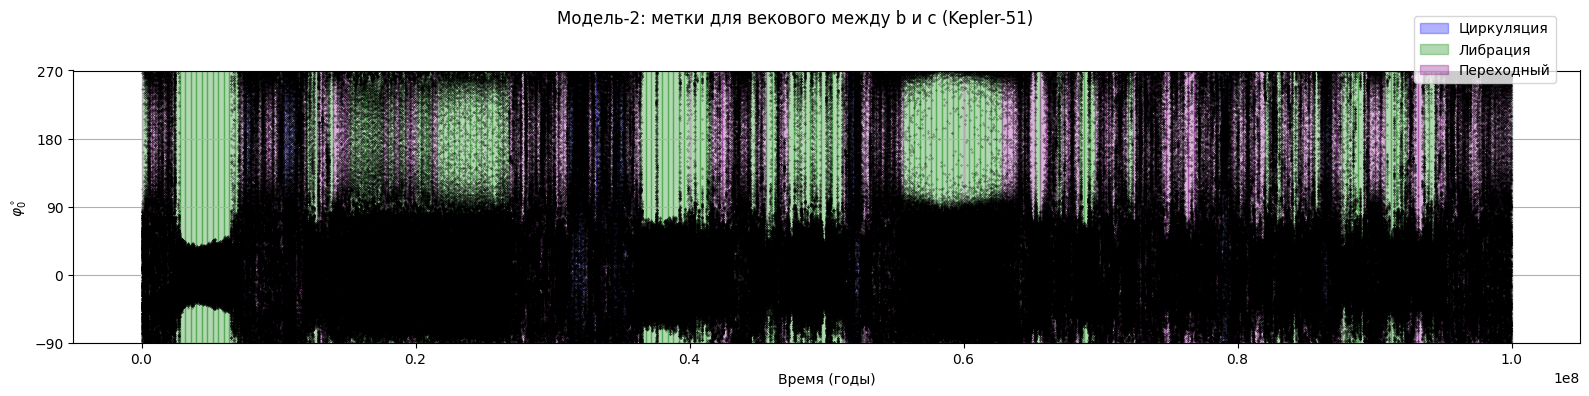

In [42]:
plot_multiplet_predictions(
    time_years=data_seq['time_years'],
    angles_deg_list=data_seq['angles_deg'],
    window_bounds=windows_seq['window_bounds'],
    class_labels_list=classes2,
    title='Модель-2: метки для векового между b и c (Kepler-51)',
    fig_width=16.,
    row_height=4,
    save_path=str(PROJECT_ROOT)+'/notebook/predict_Kepler51_seq_model2.png'

)

Вероятнее всего, проблема в ядре первого свёрточного блока (1 слой в блоке, так как остальные взаимосвязаны с ним). Модель сбалансированного набора сохранила возможности на этих данных для быстрых переменных за счёт большего 1-го размера свёрточного ядра (32>16 «оригинал»). В случае долгопериодических переменных (вековых) общие признаки даже при шаге в 100 лет не так критично изменяются (в обучении 2,5 года шаг между точками).

Способы решения.

1.  Оставить фиксированный шаг в моделированиях, но включить примеры с разным периодическим шагом (постоянным). Гарантировано сработает, но требует кратно большего набора данных.

2.  Использовать для шага данных распределение Пуассона (будет достаточно сопоставимого по объёму данных). Но придётся (весьма вероятно) переработать архитектуру модели.

Способность различать переходный режим во многом сохранилась, т.е. типовые признаки даже при значительной смене шага остаются во многом прежними, и модель способна их обнаружить.
Пострадала возможность различать либрацию и циркуляцию для критических аргументов (MMR). У сети с большим стартовым свёрточным ядром способность различать оказалась устойчивее. Для трёхчастичных углов (угол Лапласа), со схожим шагом (~2,5 года) модель по-прежнему применима. Не проверял для шага 100 лет (нет примеров либрации трёхчастичного угла на достаточно долгом интервале).

Оригинальная модель (1) более предпочтима для вековых, модель сбалансированного набора — MMR.

Самое простое решение — увеличить размер свёрточных ядер модели (в 1 слое первого блока), т.е. \begin{split} &S_{conv1d, X}(n+1)=f(S(n),S(n-1),\dots),\\
& X=1,2 (1-conv1d_1, 2 - conv1d_2). \\ \end{split}
Делать ансамбль моделей, добавив альтернативные методы (лес и т.д.).

Возможен переход к двумерным свёрткам (изображениям), скорее, даже более устойчивая модель (но кратный рост кол-ва параметров).